In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
columns = [
    "id",
    "label",
    "statement",
    "subject",
    "speaker",
    "speaker_job",
    "state",
    "party",
    "barely_true",
    "false",
    "half_true",
    "mostly_true",
    "pants_fire",
    "context"
]

train = pd.read_csv(
    "../dataset/liar/train.tsv",
    sep="\t",
    header=None,
    names=columns
)

valid = pd.read_csv(
    "../dataset/liar/valid.tsv",
    sep="\t",
    header=None,
    names=columns
)

test = pd.read_csv(
    "../dataset/liar/test.tsv",
    sep="\t",
    header=None,
    names=columns
)

train_ml = train[["statement", "label"]].copy()
valid_ml = valid[["statement", "label"]].copy()
test_ml = test[["statement", "label"]].copy()


X_train = train_ml["statement"]
y_train = train_ml["label"]

X_valid = valid_ml["statement"]
y_valid = valid_ml["label"]

X_test = test_ml["statement"]
y_test = test_ml["label"]

In [3]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

In [4]:
X_train_tfidf = vectorizer.fit_transform(X_train)

X_valid_tfidf = vectorizer.transform(X_valid)
X_test_tfidf = vectorizer.transform(X_test)

In [5]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_valid_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (10240, 20000)
Validation TF-IDF shape: (1284, 20000)
Test TF-IDF shape: (1267, 20000)


In [6]:
baseline_model = LogisticRegression(
    max_iter=1000
)

In [7]:
baseline_model.fit(
    X_train_tfidf,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [8]:
y_valid_pred = baseline_model.predict(X_valid_tfidf)

In [9]:
valid_accuracy = accuracy_score(
    y_valid,
    y_valid_pred
)

print("Validation Accuracy:", valid_accuracy)

Validation Accuracy: 0.2585669781931464


In [10]:
print(
    classification_report(
        y_valid,
        y_valid_pred
    )
)

              precision    recall  f1-score   support

 barely-true       0.24      0.17      0.20       237
       false       0.26      0.32      0.29       263
   half-true       0.25      0.36      0.30       248
 mostly-true       0.29      0.29      0.29       251
  pants-fire       0.43      0.08      0.13       116
        true       0.22      0.23      0.23       169

    accuracy                           0.26      1284
   macro avg       0.28      0.24      0.24      1284
weighted avg       0.27      0.26      0.25      1284



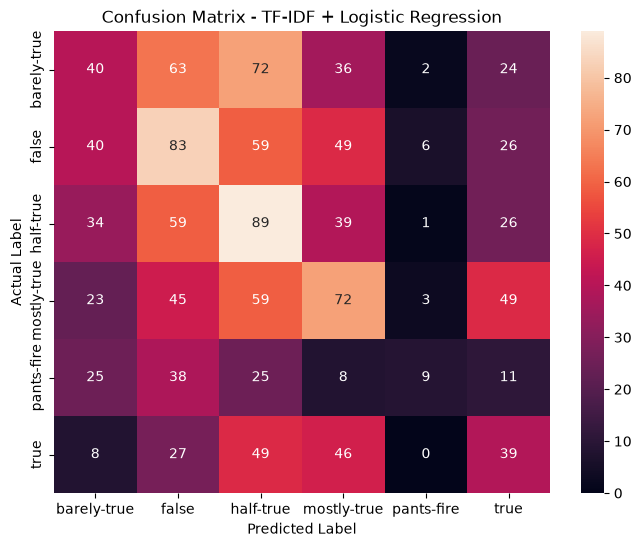

In [11]:
cm = confusion_matrix(
    y_valid,
    y_valid_pred,
    labels=baseline_model.classes_
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=baseline_model.classes_,
    yticklabels=baseline_model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - TF-IDF + Logistic Regression")

plt.show()

In [14]:
results = pd.DataFrame({
    "statement": X_valid.values,
    "actual": y_valid.values,
    "predicted": y_valid_pred
})

errors = results[
    results["actual"] != results["predicted"]
].copy()

print("Total validation errors:", len(errors))
errors.head(20)

Total validation errors: 952


,statement,actual,predicted
0,We have less Americans working now than in the...,barely-true,mostly-true
1,"When Obama was sworn into office, he DID NOT u...",pants-fire,barely-true
3,Says nearly half of Oregons children are poor.,half-true,true
5,Says when armed civilians stop mass shootings ...,false,half-true
6,Says Tennessee is providing millions of dollar...,true,half-true
7,The health care reform plan would set limits s...,false,half-true
8,Says Donald Trump started his career back in 1...,true,half-true
9,Bill White has a long history of trying to lim...,half-true,barely-true
11,"Says 21,000 Wisconsin residents got jobs in 20...",false,mostly-true
12,State revenue projections have missed the mark...,half-true,barely-true


In [15]:
pants_fire_errors = errors[
    errors["actual"] == "pants-fire"
]

pants_fire_errors["predicted"].value_counts()

predicted
false          38
barely-true    25
half-true      25
true           11
mostly-true     8
Name: count, dtype: int64

In [16]:
half_true_errors = errors[
    errors["actual"] == "half-true"
]

half_true_errors["predicted"].value_counts()

predicted
false          59
mostly-true    39
barely-true    34
true           26
pants-fire      1
Name: count, dtype: int64

In [17]:
balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

balanced_model.fit(
    X_train_tfidf,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

In [18]:
y_valid_balanced_pred = balanced_model.predict(
    X_valid_tfidf
)

In [19]:
balanced_accuracy = accuracy_score(
    y_valid,
    y_valid_balanced_pred
)

print("Balanced Model Validation Accuracy:", balanced_accuracy)

Balanced Model Validation Accuracy: 0.24299065420560748


In [20]:
print(
    classification_report(
        y_valid,
        y_valid_balanced_pred
    )
)

              precision    recall  f1-score   support

 barely-true       0.21      0.18      0.19       237
       false       0.24      0.21      0.22       263
   half-true       0.27      0.25      0.26       248
 mostly-true       0.29      0.25      0.27       251
  pants-fire       0.23      0.35      0.28       116
        true       0.21      0.30      0.25       169

    accuracy                           0.24      1284
   macro avg       0.24      0.26      0.25      1284
weighted avg       0.25      0.24      0.24      1284



In [22]:
tfidf_13 = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 3),
    min_df=2
)
X_train_tfidf_13 = tfidf_13.fit_transform(X_train)

X_valid_tfidf_13 = tfidf_13.transform(X_valid)

print("Train shape:", X_train_tfidf_13.shape)
print("Validation shape:", X_valid_tfidf_13.shape)

model_13 = LogisticRegression(
    max_iter=1000
)

model_13.fit(
    X_train_tfidf_13,
    y_train
)

Train shape: (10240, 30000)
Validation shape: (1284, 30000)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [24]:
y_valid_13_pred = model_13.predict(
    X_valid_tfidf_13
)
accuracy_13 = accuracy_score(
    y_valid,
    y_valid_13_pred
)

print("TF-IDF (1,3) Accuracy:", accuracy_13)

print(
    classification_report(
        y_valid,
        y_valid_13_pred
    )
)

TF-IDF (1,3) Accuracy: 0.2538940809968847
              precision    recall  f1-score   support

 barely-true       0.23      0.16      0.19       237
       false       0.25      0.31      0.28       263
   half-true       0.25      0.36      0.29       248
 mostly-true       0.28      0.28      0.28       251
  pants-fire       0.44      0.07      0.12       116
        true       0.23      0.23      0.23       169

    accuracy                           0.25      1284
   macro avg       0.28      0.23      0.23      1284
weighted avg       0.27      0.25      0.24      1284



## Experiment Comparison

The original TF-IDF (unigram + bigram) Logistic Regression model
achieved the best validation accuracy of 25.86%.

Adding class balancing improved the macro F1-score slightly and
substantially improved recall for the minority `pants-fire` class,
but reduced overall accuracy.

Increasing the TF-IDF n-gram range from (1,2) to (1,3) did not
improve performance. Therefore, the original TF-IDF (1,2) +
Logistic Regression configuration is retained as the primary
classical baseline.

In [25]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import joblib
joblib.dump(
    baseline_model,
    "../models/baseline_model.pkl"
)

joblib.dump(
    vectorizer,
    "../models/tfidf_vectorizer.pkl"
)

['../models/tfidf_vectorizer.pkl']